# Model Weights and Tokens: Numbers All the Way Down

This notebook explores how large language models convert text into numbers,
generate tokens step by step, and represent meaning through model weights
and embedding vectors.

By inspecting tokens, GGUF metadata, tensors, and embedding geometry,
we build an intuition for how modern LLMs actually work internally.

**Audience:** Beginners who want the real picture, not a simplified cartoon.
**Requirement:** a `.gguf` model file in the shared JupyterHub folder (or a local path you set in Section 1).

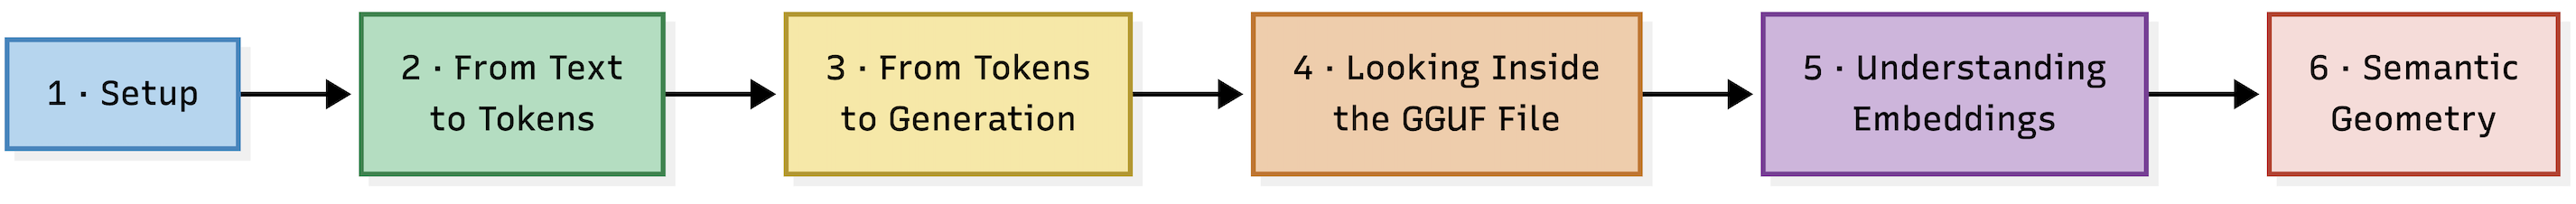

**Attribution:**
Notebook developed by Eric Van Dusen and contributors for the ds-modules/SmallLM-FA25 project.

### LLM Pipeline (Conceptual Overview)

**text** → *tokenizer* → **token IDs** → *embedding* → **vectors** → *transformer* → **logits** → *softmax* → **next token**

Large language models ultimately operate on **numbers**.  
Human-readable text is first converted into token IDs, which are mapped to vectors,
processed through transformer layers, and finally converted back into probabilities
over the vocabulary to generate the next token.


## Section 1: Setup

This section installs and imports all required libraries for the notebook.
- `llama-cpp-python` — load and run GGUF models locally
- `gguf` — read GGUF file metadata and tensors
- `numpy`, `matplotlib`, `sklearn` — numerical computation and visualization
- `ipywidgets` — interactive UI elements in the notebook

In [26]:
# Install and import all required packages
try:
    from llama_cpp import Llama
except ImportError:
    %pip install llama-cpp-python
    from llama_cpp import Llama

try:
    from gguf import GGUFReader
except ImportError:
    %pip install gguf
    from gguf import GGUFReader

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from sklearn.decomposition import PCA
import textwrap
import time, threading

print("✅ All packages ready.")

✅ All packages ready.


In [27]:
# Set model path and list available .gguf files in the directory
# ─────────────────────────────────────────────────────────────────────────────
MODEL_DIR  = "/home/jovyan/shared/"
MODEL_NAME = "qwen2-1_5b-instruct-q4_0.gguf"
# ─────────────────────────────────────────────────────────────────────────────

MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

if os.path.exists(MODEL_DIR):
    for f in sorted(f for f in os.listdir(MODEL_DIR) if f.endswith(".gguf")):
        mb     = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024**2
        marker = " ← selected" if f == MODEL_NAME else ""
        print(f"  {f:<45} {mb:>7.0f} MB{marker}")
else:
    print("  MODEL_DIR not found — please update the path above.")

print(f"\nFile exists: {os.path.exists(MODEL_PATH)}")

  DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M.gguf        1066 MB
  Llama-3.2-1B-Instruct-Q4_K_M.gguf                 770 MB
  Qwen2.5-3B-Instruct-Q4_K_M.gguf                  1840 MB
  SmolLM2-1.7B-Instruct-Q4_K_M.gguf                1007 MB
  gemma-3-4b-it-Q4_K_M.gguf                        2374 MB
  qwen2-1_5b-instruct-q4_0.gguf                     894 MB ← selected
  tinyllama-1.1b-chat-v1.0.Q4_K_M.gguf              638 MB

File exists: True


In [28]:
# Load the model into memory
print("⏳ Loading model...")
model = Llama(model_path=MODEL_PATH, n_ctx=512, verbose=False, logits_all=True)
print(f"✅ Loaded  :  {MODEL_NAME}")
print(f"Vocabulary :  {model.n_vocab():,} tokens")
print(f"Context    :  {model.n_ctx():,} tokens")

⏳ Loading model...


llama_context: n_ctx_per_seq (512) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✅ Loaded  :  qwen2-1_5b-instruct-q4_0.gguf
Vocabulary :  151,936 tokens
Context    :  512 tokens


## Section 2. From Text to Tokens

A language model never reads raw text — it only sees **integers**.
The first step is breaking text into **tokens**.

Token boundaries do not follow word boundaries:
- A common word like `the` → usually **one token**
- A rare word like `hyperinflation` → split into `hyper` + `inflation`
- Spaces and punctuation matter too

Modern LLMs use **Byte-Pair Encoding (BPE)**: a vocabulary of common
sub-word units learned from training data.

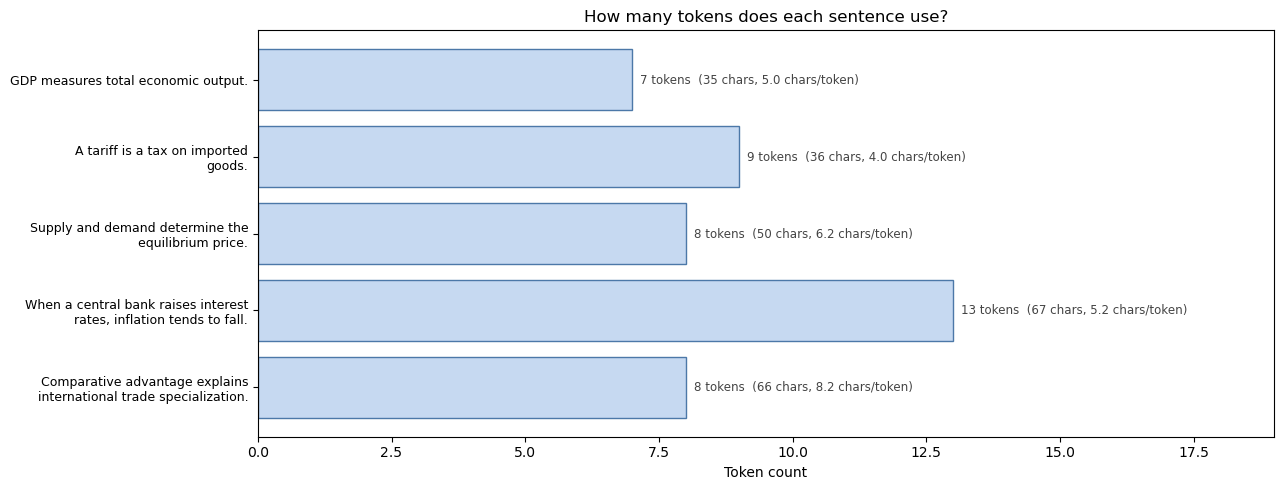

In [29]:
# Visualize how many tokens each sentence uses
# — longer or rarer words produce more tokens

sentences = [
    "GDP measures total economic output.",
    "A tariff is a tax on imported goods.",
    "Supply and demand determine the equilibrium price.",
    "When a central bank raises interest rates, inflation tends to fall.",
    "Comparative advantage explains international trade specialization.",
]

token_counts = [len(model.tokenize(s.encode("utf-8"))) for s in sentences]
char_counts  = [len(s) for s in sentences]
labels       = [textwrap.fill(s, width=35) for s in sentences]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(range(len(sentences)), token_counts, color="#c6d9f1", edgecolor="#4c78a8")
ax.set_yticks(range(len(sentences)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Token count")
ax.set_title("How many tokens does each sentence use?")
for bar, tc, cc in zip(bars, token_counts, char_counts):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{tc} tokens  ({cc} chars, {cc/tc:.1f} chars/token)",
            va="center", fontsize=8.5, color="#444")
ax.set_xlim(0, max(token_counts) + 6)
plt.subplots_adjust(left=0.35)
plt.tight_layout()
plt.show()

In [35]:
# Break down one sentence token by token
# — see exactly which integer ID maps to which piece of text
sample = "A tariff is a tax on imported goods."
ids    = model.tokenize(sample.encode("utf-8"))
pieces = [model.detokenize([tid]).decode("utf-8", errors="replace") for tid in ids]

print(f"Input : {sample}")
print(f"IDs   : {ids}")
print(f"\n{'#':>3}  {'Token ID':>10}  {'Decoded piece'}")
print("-" * 38)
for i, (tid, piece) in enumerate(zip(ids, pieces)):
    print(f"{i:>3}  {tid:>10}  {repr(piece)}")

print("\n Note: spaces attach to the start of the next word. Punctuation is its own token.")

Input : A tariff is a tax on imported goods.
IDs   : [32, 60261, 374, 264, 3742, 389, 24928, 11561, 13]

  #    Token ID  Decoded piece
--------------------------------------
  0          32  'A'
  1       60261  ' tariff'
  2         374  ' is'
  3         264  ' a'
  4        3742  ' tax'
  5         389  ' on'
  6       24928  ' imported'
  7       11561  ' goods'
  8          13  '.'

 Note: spaces attach to the start of the next word. Punctuation is its own token.


### 🎮 Try it yourself!
Type any text below and see how it gets split into tokens.
Each colored block is one token — the subscript number is its ID.

In [41]:
# Interactive token visualizer — type any text and see it split into tokens
PALETTE = ["#dbeafe", "#dcfce7", "#fef9c3", "#ffe4e6", "#ede9fe", "#e0f2fe"]

def show_tokens(text):
    if not text.strip():
        display(HTML("<i>Enter some text above.</i>"))
        return
    tids   = model.tokenize(text.encode("utf-8"))
    pieces = [model.detokenize([tid]).decode("utf-8", errors="replace") for tid in tids]
    spans  = "".join(
        f'<span style="display:inline-block; margin:3px 2px; padding:5px 9px; '
        f'background:{PALETTE[i % len(PALETTE)]}; border:1px solid #d0d7de; '
        f'border-radius:8px; font-family:monospace; font-size:13px;">'
        f'{repr(piece)[1:-1]}<sub style="color:#888; font-size:10px;"> {tid}</sub></span>'
        for i, (tid, piece) in enumerate(zip(tids, pieces))
    )
    rows = "".join(
        f"<tr><td style='padding:3px 10px; text-align:right;'>{i}</td>"
        f"<td style='padding:3px 10px;'>{tid}</td>"
        f"<td style='padding:3px 10px; font-family:monospace;'>{repr(piece)}</td></tr>"
        for i, (tid, piece) in enumerate(zip(tids, pieces))
    )
    display(HTML(f"""
    <div style="font-family:sans-serif; padding:16px; background:#fafbfc;
                border:1px solid #d0d7de; border-radius:12px;">
      <div style="margin-bottom:10px; color:#555;">
        {len(text)} characters → <b>{len(tids)} tokens</b>
        &nbsp;(avg {len(text)/len(tids):.1f} chars/token)
      </div>
      <div style="line-height:2.4; margin-bottom:14px;">{spans}</div>
      <details>
        <summary style="cursor:pointer; color:#555; font-size:13px;">▶ Full token table</summary>
        <table style="border-collapse:collapse; font-size:12px; margin-top:8px;">
          <tr><th style='padding:3px 10px;'>#</th>
              <th style='padding:3px 10px;'>Token ID</th>
              <th style='padding:3px 10px;'>Decoded piece</th></tr>
          {rows}
        </table>
      </details>
    </div>
    """))

text_box = widgets.Text(
    value="Comparative advantage explains why countries specialize.",
    layout=widgets.Layout(width="680px"), description="Text:"
)
btn = widgets.Button(description="Tokenize", button_style="info")
out = widgets.Output()

def _on_click(_):
    out.clear_output()
    with out:
        show_tokens(text_box.value)

btn.on_click(_on_click)
display(widgets.VBox([text_box, btn, out]))
_on_click(None)

## Section 3. From Tokens to Generation

Now the model has a list of integers — what happens next?

Think of it like autocomplete on your phone: the model looks at all the
tokens so far and predicts the single most likely next word. Then it repeats,
over and over, until the response is complete. The model always generates
**one integer at a time**.

### Generating a response
Let's ask the model to complete a sentence. With `temperature=0.0`,
it always picks the most likely next token — no randomness at all.

In [42]:
# Full greedy response
# temperature=0.0 means always pick the highest-probability token (no randomness)
# echo=True means the output includes the original prompt
prompt   = "A tariff affects trade because"
response = model(prompt, max_tokens=28, temperature=0.0, echo=True)
print(response["choices"][0]["text"])

A tariff affects trade because it changes the price of a good or service. A tariff is a tax on goods and services. Tariffs are levied on imports and


In [43]:
PROMPT = "A tariff affects trade because"
MAX_TOKENS = 28

# -- Fetch real tokens from model via streaming --
TOKENS = []
stream = model(PROMPT, max_tokens=MAX_TOKENS, temperature=0.0, stream=True)
for chunk in stream:
    piece = chunk["choices"][0]["text"]
    if piece:
        TOKENS.append(piece)

out      = widgets.Output()
progress = widgets.IntProgress(value=0, min=0, max=MAX_TOKENS,
                               layout=widgets.Layout(width="100%", height="10px"),
                               style={"bar_color": "#54a24b"})
counter  = widgets.HTML(value="<span style='font-family:monospace;color:#aaa'>0 / 28 tokens</span>")
btn = widgets.Button(description="▶  GENERATE",
                     style={"button_color": "#3a8a3a", "font_weight": "bold"},
                     layout=widgets.Layout(width="140px", height="36px"))
speed_toggle = widgets.ToggleButtons(
    options=[("slow", 0.35), ("normal", 0.15), ("fast", 0.04)],
    value=0.15,
    style={"button_width": "70px", "font_size": "12px"},
)

_running = {"v": False}

def render_output(n_tokens):
    """Build coloured HTML for the output box."""
    parts = [f"<span style='color:#888'>{PROMPT}</span>"]
    for i, tok in enumerate(TOKENS[:n_tokens]):
        if i == len(TOKENS) - 1 and len(TOKENS) == MAX_TOKENS:
            parts.append(
                f"<span style='color:#e67e22;font-weight:bold'>{tok}</span>"
                "<span style='background:#e67e22;color:white;font-size:11px;"
                "font-weight:800;border-radius:4px;padding:1px 6px;"
                "margin-left:6px;vertical-align:middle'>MAX_TOKENS</span>"
            )
        else:
            parts.append(f"<span style='color:#1a1a2e'>{tok}</span>")
    cursor = "<span style='border-left:2px solid #54a24b;margin-left:1px'>&nbsp;</span>"
    box_style = (
        "background:#fafbfc;border:1px solid #d0d7de;border-radius:10px;"
        "padding:16px 20px;font-family:monospace;font-size:15px;"
        "line-height:1.9;min-height:80px;"
    )
    inner = "".join(parts) + (cursor if n_tokens < len(TOKENS) else "")
    return f"<div style='{box_style}'>{inner}</div>"

def callout(msg, color):
    return (
        f"<div style='margin-top:12px;background:{color}11;"
        f"border-left:3px solid {color};border-radius:6px;"
        f"padding:10px 14px;font-size:13px;color:{color};font-family:monospace'>"
        f"{msg}</div>"
    )

def run_generation(_):
    if _running["v"]:
        return
    _running["v"] = True
    btn.description = "..."
    btn.disabled = True
    progress.value = 0
    progress.style = {"bar_color": "#54a24b"}

    delay = speed_toggle.value

    for i in range(1, len(TOKENS) + 1):
        if not _running["v"]:
            break
        with out:
            clear_output(wait=True)
            display(HTML(render_output(i)))
        progress.value = i
        color = "#e67e22" if i == len(TOKENS) else "#54a24b"
        counter.value = f"<span style='font-family:monospace;color:{color}'><b>{i}</b> / {MAX_TOKENS} tokens</span>"
        if i == len(TOKENS):
            progress.style = {"bar_color": "#e67e22"}
        time.sleep(delay)

    with out:
        clear_output(wait=True)
        display(HTML(
            render_output(len(TOKENS)) +
            callout(
                f"✂️  Output cut off at token #{len(TOKENS)} — that's max_tokens={MAX_TOKENS} at work. "
                "The model would keep going forever without a limit.",
                "#e67e22"
            )
        ))

    btn.description = "↺  REPLAY"
    btn.disabled = False
    _running["v"] = False

btn.on_click(run_generation)

with out:
    display(HTML(render_output(0)))

display(
    widgets.HTML(
        "<div style='font-family:sans-serif;margin-bottom:8px'>"
        "<span style='color:#54a24b;font-size:11px;letter-spacing:2px'>GREEDY DECODING</span>"
        "  <span style='background:#f0f4ff;border:1px solid #818cf8;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#818cf8'>temperature=0.0</span>"
        "  <span style='background:#fff8f0;border:1px solid #e67e22;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#e67e22'>max_tokens=28</span>"
        "</div>"
    ),
    out,
    widgets.HBox([progress, counter],
                 layout=widgets.Layout(align_items="center", gap="12px", margin="8px 0")),
    widgets.HBox([btn, widgets.Label("speed:"), speed_toggle],
                 layout=widgets.Layout(align_items="center", gap="8px")),
)

HTML(value="<div style='font-family:sans-serif;margin-bottom:8px'><span style='color:#54a24b;font-size:11px;le…

Output()

> 💡 Notice the output was cut off — that's `max_tokens=28` at work. 
> The model would keep going forever if we didn't set a limit!

### Watching generation happen step by step
The cell below streams the output token by token — you can see each piece 
arrive one at a time, just like ChatGPT's typing effect.

In [44]:
# Stream output token by token — each chunk is one piece of generated text
prompt    = "Inflation matters to households because"
stream    = model(prompt, max_tokens=24, temperature=0.0, stream=True)
generated = ""

print(f"Prompt: {prompt!r}\n")
print(f"{'Step':>4}  {'Piece (repr)'}")
print("-" * 36)
for step, chunk in enumerate(stream, 1):
    piece      = chunk["choices"][0]["text"]
    generated += piece
    print(f"{step:>4}  {repr(piece)}")

print(f"\nDecoded: {prompt}{generated}")

Prompt: 'Inflation matters to households because'

Step  Piece (repr)
------------------------------------
   1  ' it'
   2  ' affects'
   3  ' the'
   4  ' real'
   5  ' value'
   6  ' of'
   7  ' their'
   8  ' income'
   9  '.'
  10  ' In'
  11  'flation'
  12  ' is'
  13  ' the'
  14  ' rate'
  15  ' at'
  16  ' which'
  17  ' the'
  18  ' purchasing'
  19  ' power'
  20  ' of'
  21  ' money'
  22  ' decreases'
  23  ' over'
  24  ' time'
  25  ''

Decoded: Inflation matters to households because it affects the real value of their income. Inflation is the rate at which the purchasing power of money decreases over time


In [48]:
PROMPT = "Inflation matters to households because"
MAX_TOKENS = 24

# -- Fetch real tokens from model via streaming --
TOKENS = []
stream = model(PROMPT, max_tokens=MAX_TOKENS, temperature=0.0, stream=True)
for chunk in stream:
    piece = chunk["choices"][0]["text"]
    if piece:
        TOKENS.append(piece)

# -- UI components --
out     = widgets.Output()
log_out = widgets.Output()
btn     = widgets.Button(
    description="▶  STREAM",
    style={"button_color": "#3a8a3a", "font_weight": "bold"},
    layout=widgets.Layout(width="140px", height="36px"),
)
speed_toggle = widgets.ToggleButtons(
    options=[("slow", 0.35), ("normal", 0.15), ("fast", 0.04)],
    value=0.15,
    style={"button_width": "70px", "font_size": "12px"},
)

_running = {"v": False}

MONO = "font-family:monospace;font-size:13px"
BOX  = (
    "background:#fafbfc;border:1px solid #d0d7de;border-radius:10px;"
    "padding:16px 20px;font-family:monospace;font-size:15px;line-height:1.9;"
)

def render_stream(n):
    parts = [f"<span style='color:#888'>{PROMPT}</span>"]
    for tok in TOKENS[:n]:
        parts.append(f"<span style='color:#1a1a2e'>{tok}</span>")
    cursor = "<span style='border-left:2px solid #54a24b;margin-left:1px'>&nbsp;</span>"
    inner = "".join(parts) + (cursor if n < len(TOKENS) else "")
    return f"<div style='{BOX}'>{inner}</div>"

def render_log(n):
    """Step table showing repr of each piece received so far."""
    header = (
        "<div style='background:#fafbfc;border:1px solid #d0d7de;border-radius:10px;"
        "padding:12px 16px;margin-top:12px'>"
        f"<div style='{MONO};color:#888;margin-bottom:6px'>"
        "<span style='display:inline-block;width:48px'>Step</span>"
        "<span style='display:inline-block;width:200px'>Piece (repr)</span>"
        "<span>Decoded so far</span></div>"
        "<div style='border-top:1px solid #d0d7de;margin-bottom:6px'></div>"
    )
    rows = []
    for i, tok in enumerate(TOKENS[:n], 1):
        decoded_so_far = "".join(TOKENS[:i])
        rows.append(
            f"<div style='{MONO};color:#1a1a2e;margin:3px 0'>"
            f"<span style='display:inline-block;width:48px;color:#888'>{i:>3}</span>"
            f"<span style='display:inline-block;width:200px;color:#4c78a8'>{repr(tok)}</span>"
            f"<span style='color:#888'>{PROMPT}"
            f"<span style='color:#1a1a2e'>{decoded_so_far}</span>"
            f"</span></div>"
        )
    return header + "".join(rows) + "</div>"

def run_stream(_):
    if _running["v"]:
        return
    _running["v"] = True
    btn.description = "..."
    btn.disabled = True
    delay = speed_toggle.value
    for i in range(1, len(TOKENS) + 1):
        if not _running["v"]:
            break
        with out:
            clear_output(wait=True)
            display(HTML(render_stream(i)))
        with log_out:
            clear_output(wait=True)
            display(HTML(render_log(i)))
        time.sleep(delay)
    btn.description = "↺  REPLAY"
    btn.disabled = False
    _running["v"] = False

btn.on_click(run_stream)

# -- Initial state --
with out:
    display(HTML(render_stream(0)))
with log_out:
    display(HTML(render_log(0)))

display(
    widgets.HTML(
        "<div style='font-family:sans-serif;margin-bottom:8px'>"
        "<span style='color:#54a24b;font-size:11px;letter-spacing:2px'>STREAMING</span>"
        "  <span style='background:#f0f4ff;border:1px solid #818cf8;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#818cf8'>temperature=0.0</span>"
        "  <span style='background:#fff8f0;border:1px solid #e67e22;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#e67e22'>max_tokens=24</span>"
        "</div>"
    ),
    out,
    log_out,
    widgets.HBox([btn, widgets.Label("speed:"), speed_toggle],
                 layout=widgets.Layout(align_items="center", gap="8px", margin="8px 0")),
)

HTML(value="<div style='font-family:sans-serif;margin-bottom:8px'><span style='color:#54a24b;font-size:11px;le…

Output()

Output()

### Under the hood: raw integer output
The previous cell showed decoded text. This cell shows what the model 
**actually produces** — raw integer IDs, one at a time.
Notice that the model generates numbers first, and only then do we decode 
them back into readable text.

In [49]:
# Low-level generation: see the raw integer IDs the model produces
# top_k=1 = greedy decoding — always pick the single highest-probability token
prompt_tokens      = model.tokenize("Define comparative advantage:".encode("utf-8"))
output_ids, pieces = [], []

for token_id in model.generate(prompt_tokens, top_k=1):
    pieces.append(model.detokenize([token_id]).decode("utf-8", errors="replace"))
    output_ids.append(token_id)
    if token_id == model.token_eos() or len(output_ids) >= 48:
        break

print(f"Raw output IDs:\n{output_ids}\n")
print(f"{'Step':>4}  {'Token ID':>10}  {'Decoded piece'}")
print("-" * 40)
for i, (tid, piece) in enumerate(zip(output_ids, pieces), 1):
    print(f"{i:>4}  {tid:>10}  {repr(piece)}")

Raw output IDs:
[576, 54294, 9423, 315, 264, 3146, 374, 279, 6672, 1948, 279, 5670, 7049, 315, 1181, 1828, 11561, 323, 279, 5670, 7049, 315, 279, 11561, 8947, 553, 1008, 5837, 13, 1084, 374, 279, 5726, 315, 264, 3146, 311, 8193, 264, 1661, 518, 264, 4722, 2783, 1091, 2441, 3146, 13]

Step    Token ID  Decoded piece
----------------------------------------
   1         576  ' The'
   2       54294  ' comparative'
   3        9423  ' advantage'
   4         315  ' of'
   5         264  ' a'
   6        3146  ' country'
   7         374  ' is'
   8         279  ' the'
   9        6672  ' difference'
  10        1948  ' between'
  11         279  ' the'
  12        5670  ' production'
  13        7049  ' costs'
  14         315  ' of'
  15        1181  ' its'
  16        1828  ' own'
  17       11561  ' goods'
  18         323  ' and'
  19         279  ' the'
  20        5670  ' production'
  21        7049  ' costs'
  22         315  ' of'
  23         279  ' the'
  24       11561  ' good

In [46]:
PROMPT = "Define comparative advantage:"

# -- Fetch real tokens from model --
prompt_tokens = model.tokenize(PROMPT.encode("utf-8"))
output_ids, pieces = [], []
for token_id in model.generate(prompt_tokens, top_k=1):
    pieces.append(model.detokenize([token_id]).decode("utf-8", errors="replace"))
    output_ids.append(token_id)
    if token_id == model.token_eos() or len(output_ids) >= 48:
        break

EOS_ID = model.token_eos()

# -- UI components --
out     = widgets.Output()
log_out = widgets.Output()
btn     = widgets.Button(
    description="▶  GENERATE",
    style={"button_color": "#3a8a3a", "font_weight": "bold"},
    layout=widgets.Layout(width="140px", height="36px"),
)
speed_toggle = widgets.ToggleButtons(
    options=[("slow", 0.35), ("normal", 0.15), ("fast", 0.04)],
    value=0.15,
    style={"button_width": "70px", "font_size": "12px"},
)

_running = {"v": False}

MONO = "font-family:monospace;font-size:13px"
BOX  = (
    "background:#fafbfc;border:1px solid #d0d7de;border-radius:10px;"
    "padding:16px 20px;font-family:monospace;font-size:15px;line-height:1.9;"
)

def render_stream(n):
    parts = [f"<span style='color:#888'>{PROMPT}</span>"]
    for i, (tid, piece) in enumerate(zip(output_ids[:n], pieces[:n])):
        is_eos = tid == EOS_ID
        color  = "#e67e22" if is_eos else "#1a1a2e"
        parts.append(f"<span style='color:{color}'>{piece}</span>")
    cursor = "<span style='border-left:2px solid #54a24b;margin-left:1px'>&nbsp;</span>"
    inner  = "".join(parts) + (cursor if n < len(output_ids) else "")
    return f"<div style='{BOX}'>{inner}</div>"

def render_log(n):
    header = (
        "<div style='background:#fafbfc;border:1px solid #d0d7de;border-radius:10px;"
        "padding:12px 16px;margin-top:12px'>"
        f"<div style='{MONO};color:#888;margin-bottom:6px'>"
        "<span style='display:inline-block;width:48px'>Step</span>"
        "<span style='display:inline-block;width:110px'>Token ID</span>"
        "<span>Decoded piece</span></div>"
        "<div style='border-top:1px solid #d0d7de;margin-bottom:6px'></div>"
    )
    rows = []
    for i, (tid, piece) in enumerate(zip(output_ids[:n], pieces[:n]), 1):
        is_eos    = tid == EOS_ID
        id_color  = "#e67e22" if is_eos else "#54a24b"
        eos_badge = (
            "<span style='background:#e67e22;color:white;font-size:10px;"
            "font-weight:800;border-radius:4px;padding:1px 5px;margin-left:6px'>"
            "EOS</span>"
        ) if is_eos else ""
        rows.append(
            f"<div style='{MONO};color:#1a1a2e;margin:3px 0'>"
            f"<span style='display:inline-block;width:48px;color:#888'>{i:>3}</span>"
            f"<span style='display:inline-block;width:110px;color:{id_color}'>{tid}{eos_badge}</span>"
            f"<span style='color:#4c78a8'>{repr(piece)}</span>"
            f"</div>"
        )
    return header + "".join(rows) + "</div>"

def run_generation(_):
    if _running["v"]:
        return
    _running["v"] = True
    btn.description = "..."
    btn.disabled = True

    delay = speed_toggle.value

    for i in range(1, len(output_ids) + 1):
        if not _running["v"]:
            break
        with out:
            clear_output(wait=True)
            display(HTML(render_stream(i)))
        with log_out:
            clear_output(wait=True)
            display(HTML(render_log(i)))
        time.sleep(delay)

    btn.description = "↺  REPLAY"
    btn.disabled = False
    _running["v"] = False

btn.on_click(run_generation)

# -- Initial state --
with out:
    display(HTML(render_stream(0)))
with log_out:
    display(HTML(render_log(0)))

display(
    widgets.HTML(
        "<div style='font-family:sans-serif;margin-bottom:8px'>"
        "<span style='color:#54a24b;font-size:11px;letter-spacing:2px'>RAW TOKEN IDS</span>"
        "  <span style='background:#f0f4ff;border:1px solid #818cf8;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#818cf8'>top_k=1</span>"
        "  <span style='background:#fff8f0;border:1px solid #e67e22;border-radius:5px;"
        "padding:2px 8px;font-size:12px;color:#e67e22'>EOS stops generation</span>"
        "</div>"
    ),
    out,
    log_out,
    widgets.HBox([btn, widgets.Label("speed:"), speed_toggle],
                 layout=widgets.Layout(align_items="center", gap="8px", margin="8px 0")),
)

HTML(value="<div style='font-family:sans-serif;margin-bottom:8px'><span style='color:#54a24b;font-size:11px;le…

Output()

Output()

### What does the model "see" before picking the next token?
Before generating each word, the model assigns a probability to every token 
in its vocabulary. The bar chart below shows the top candidates — 
the model picks the highest one (greedy) or samples from the distribution (temperature).

In [47]:
display(HTML("""
<div style="font-family:sans-serif; padding:24px; background:#f8f9fa;
            border:1px solid #d0d7de; border-radius:12px;">
  <div style="font-size:11px; color:#54a24b; letter-spacing:2px; margin-bottom:6px;">
    SECTION 4
  </div>
  <h2 style="margin:0 0 12px 0; font-size:1.2rem; color:#1a1a2e;">
    Looking Inside the GGUF File
  </h2>
  <p style="color:#444; margin:0 0 20px 0; font-size:13px;">
    Think of a <b>.gguf</b> file like a ZIP archive —
    one file contains everything needed to run the model:
  </p>
  <div style="display:flex; gap:12px; margin-bottom:24px;">
    <div style="flex:1; background:#EBF5FB; border-left:3px solid #2E86C1;
                border-radius:8px; padding:14px;">
      <div style="color:#2E86C1; font-weight:bold; margin-bottom:6px;">📋 Metadata</div>
      <div style="color:#555; font-size:12px; line-height:1.6;">
        Layer count, dimensions,<br>context length, head count
      </div>
    </div>
    <div style="flex:1; background:#EAFAF1; border-left:3px solid #1E8449;
                border-radius:8px; padding:14px;">
      <div style="color:#1E8449; font-weight:bold; margin-bottom:6px;">📖 Vocabulary</div>
      <div style="color:#555; font-size:12px; line-height:1.6;">
        Token ID → text<br>lookup table
      </div>
    </div>
    <div style="flex:1; background:#FEF9E7; border-left:3px solid #B7950B;
                border-radius:8px; padding:14px;">
      <div style="color:#B7950B; font-weight:bold; margin-bottom:6px;">🔢 Weight Tensors</div>
      <div style="color:#555; font-size:12px; line-height:1.6;">
        The model's learned<br>"knowledge"
      </div>
    </div>
  </div>
  <p style="color:#555; margin:0 0 12px 0; font-size:13px;">
    Each tensor name tells you where it lives.
    Think of <code>blk.N</code> as "layer number N":
  </p>
  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="background:#e9ecef;">
      <th style="padding:8px 14px; text-align:center; color:#555; font-weight:bold;">Tensor name</th>
      <th style="padding:8px 14px; text-align:center; color:#555; font-weight:bold;">Role</th>
    </tr>
    <tr style="border-top:1px solid #d0d7de;">
      <td style="padding:9px 14px; color:#2E86C1; text-align:left;"><code>token_embd.weight</code></td>
      <td style="padding:9px 14px; color:#444; text-align:left;">Embedding matrix — one row per token</td>
    </tr>
    <tr style="border-top:1px solid #d0d7de; background:#f8f9fa;">
      <td style="padding:9px 14px; color:#2E86C1; text-align:left;"><code>blk.N.attn_q/k/v.weight</code></td>
      <td style="padding:9px 14px; color:#444; text-align:left;">Attention query / key / value in layer N</td>
    </tr>
    <tr style="border-top:1px solid #d0d7de;">
      <td style="padding:9px 14px; color:#2E86C1; text-align:left;"><code>blk.N.ffn_up/down.weight</code></td>
      <td style="padding:9px 14px; color:#444; text-align:left;">Feed-forward network in layer N</td>
    </tr>
    <tr style="border-top:1px solid #d0d7de; background:#f8f9fa;">
      <td style="padding:9px 14px; color:#2E86C1; text-align:left;"><code>output.weight</code></td>
      <td style="padding:9px 14px; color:#444; text-align:left;">Final projection → vocabulary logits</td>
    </tr>
  </table>
</div>
"""))

Tensor name,Role
token_embd.weight,Embedding matrix — one row per token
blk.N.attn_q/k/v.weight,Attention query / key / value in layer N
blk.N.ffn_up/down.weight,Feed-forward network in layer N
output.weight,Final projection → vocabulary logits


### Reading the GGUF metadata

A GGUF file keeps its metadata at the very start — so we can inspect 
the model's architecture without loading any weights into memory.

The cell below opens the file and reads just that header section,
printing the key parameters that define the model's shape:
how many layers it has, how wide each vector is, and how much 
context it can hold.

In [51]:
# Read the GGUF file and print key architecture parameters
# — no model loading needed, just file inspection
def summarize_gguf(reader, model_path):
    keywords = ["architecture", "embedding_length", "block_count",
                "head_count", "context_length", "feed_forward_length"]

    descriptions = {
        "architecture":        "model family",
        "block_count":         "number of Transformer layers",
        "context_length":      "max tokens the model can see at once",
        "embedding_length":    "vector size per token",
        "feed_forward_length": "width of each FFN layer",
        "head_count":          "number of attention heads (query)",
        "head_count_kv":       "number of attention heads (key/value, GQA)",
    }

    print("GGUF summary")
    print(f"  File size       : {os.path.getsize(model_path)/1024**2:.0f} MB")
    print(f"  Metadata fields : {len(reader.fields):,}")
    print(f"  Weight tensors  : {len(reader.tensors):,}")
    print("\nKey architecture parameters:")

    for name, field in reader.fields.items():
        if any(k in name.lower() for k in keywords):
            # field.parts contains raw data chunks; field.data[0] is the index of the value chunk
            try:
                value = field.parts[field.data[0]][0]
            except Exception:
                value = "unavailable"
            short = name.split(".")[-1]
            desc  = descriptions.get(short, "")
            print(f"  {name:<48} {value:<10}  # {desc}")

reader = GGUFReader(MODEL_PATH)
summarize_gguf(reader, MODEL_PATH)

GGUF summary
  File size       : 894 MB
  Metadata fields : 29
  Weight tensors  : 338

Key architecture parameters:
  general.architecture                             113         # model family
  qwen2.block_count                                28          # number of Transformer layers
  qwen2.context_length                             32768       # max tokens the model can see at once
  qwen2.embedding_length                           1536        # vector size per token
  qwen2.feed_forward_length                        8960        # width of each FFN layer
  qwen2.attention.head_count                       12          # number of attention heads (query)
  qwen2.attention.head_count_kv                    2           # number of attention heads (key/value, GQA)


### What's inside the weight file?

Most of a model's file size is weights — but not all weights are equal.
Some tensors are enormous (the embedding matrix alone can have hundreds 
of millions of parameters), while normalization layers are tiny.

The charts below show two things:
- **Which individual tensors are the largest** — so you can see where 
  the parameters actually live
- **How the total is split by type** — attention vs feed-forward vs embeddings

This gives you a sense of where the model spends its "capacity",
and why feed-forward layers typically dominate the parameter count.

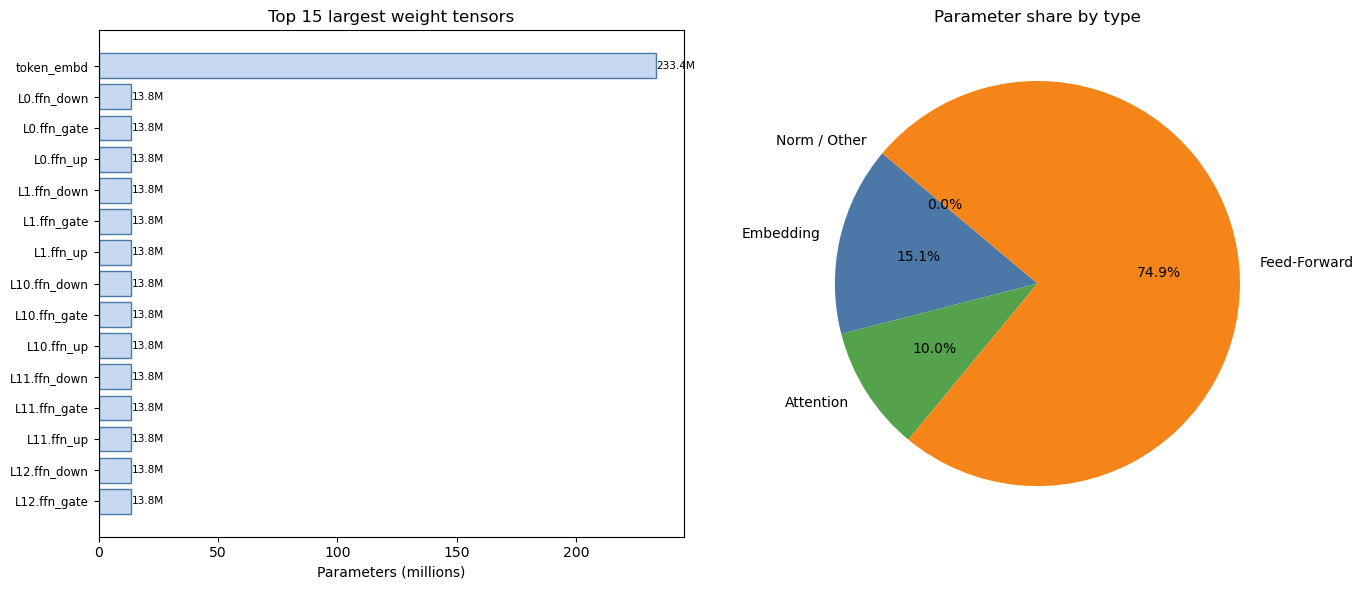

In [52]:
# Helper: plot tensor size distribution
def plot_tensor_distribution(reader):

    # Count parameters in each tensor (shape is a list of dimensions, e.g. [1536, 1536])
    # np.prod multiplies them together to get total parameter count
    tensor_data = sorted(
        [(t.name, int(np.prod(t.shape))) for t in reader.tensors],
        key=lambda x: x[1], reverse=True
    )

    top15 = tensor_data[:15]

    # Shorten names for the chart: "blk.0.attn_q.weight" → "L0.attn_q"
    names = [n.replace("blk.", "L").replace(".weight", "") for n, _ in top15]
    sizes = [s / 1e6 for _, s in top15]  # convert to millions

    # Bucket every tensor into one of four categories
    cats = {"Embedding": 0, "Attention": 0, "Feed-Forward": 0, "Norm / Other": 0}
    for t in reader.tensors:
        s = int(np.prod(t.shape))
        if "token_embd" in t.name or t.name == "output.weight":
            cats["Embedding"] += s       # input + output embedding matrices
        elif "attn" in t.name:
            cats["Attention"] += s       # Q / K / V / output projection weights
        elif "ffn" in t.name:
            cats["Feed-Forward"] += s    # up / down / gate projection weights
        else:
            cats["Norm / Other"] += s    # layer norm, etc. — usually tiny

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: horizontal bar chart of the 15 largest tensors
    bars = ax1.barh(range(15), sizes, color="#c6d9f1", edgecolor="#4c78a8")
    ax1.set_yticks(range(15))
    ax1.set_yticklabels(names, fontsize=8.5)
    ax1.invert_yaxis()
    ax1.set_xlabel("Parameters (millions)")
    ax1.set_title("Top 15 largest weight tensors")
    for bar, s in zip(bars, sizes):
        ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"{s:.1f}M", va="center", fontsize=7.5)

    # Right: pie chart of total parameters by category
    ax2.pie(cats.values(), labels=cats.keys(),
            colors=["#4c78a8", "#54a24b", "#f58518", "#bbb"],
            autopct="%1.1f%%", startangle=140)
    ax2.set_title("Parameter share by type")

    plt.tight_layout()
    plt.show()

plot_tensor_distribution(reader)

**What the charts tell us**

The embedding matrix (`token_embd`) dominates the bar chart — it needs 
one vector for every token in the vocabulary, so it grows with vocab size, 
not model depth.

The pie chart shows that **Feed-Forward layers hold ~75% of all parameters**.
This surprises most people, because attention gets most of the attention (pun intended).

The difference in role:
- **Attention** decides *which* tokens to look at — it routes information
- **FFN** is where the model actually *stores* knowledge — facts, patterns, associations

This is why larger models (wider FFN layers) tend to "know more":
the extra capacity goes into the feed-forward memory, not the attention mechanism.

### The Embedding Matrix

The embedding matrix is the model's **front door** — every token ID that 
enters the model gets looked up here and converted into a vector of numbers.
Without this step, the model has nothing to work with.

The shape of this matrix tells you two things:
- **Rows** = vocabulary size — how many tokens the model knows
- **Columns** = embedding dimension — how many numbers describe each token

A larger embedding dimension means each token gets a richer, more detailed 
representation. But it also means more parameters — every extra dimension 
adds one number per token across the entire vocabulary.

In [16]:
# The embedding matrix: one row per vocabulary token
def show_embedding_matrix_info(reader):
    embd = next((t for t in reader.tensors if t.name == "token_embd.weight"), None)
    if embd is None:
        print("Embedding tensor not found.")
        return

    # shape[0] is the embedding dimension, shape[1] is the vocabulary size
    embd_dim, vocab_size = embd.shape[0], embd.shape[1]
    total    = vocab_size * embd_dim      # total number of individual float values
    fp32_mb  = total * 4 / 1024**2        # fp32 = 4 bytes per value
    actual_mb = embd.data.nbytes / 1024**2  # actual size stored on disk after quantization

    print("token_embd.weight")
    print(f"  Shape      : {vocab_size:,} tokens × {embd_dim} dimensions")
    print(f"  Values     : {total:,} total numbers")
    print(f"  If fp32    : {fp32_mb:.0f} MB")
    print(f"  Stored as  : {embd.tensor_type.name}  →  {actual_mb:.0f} MB on disk")
    print(f"  Compression: {fp32_mb / actual_mb:.1f}x smaller than fp32")

show_embedding_matrix_info(reader)


token_embd.weight
  Shape      : 151,936 tokens × 1536 dimensions
  Values     : 233,373,696 total numbers
  If fp32    : 890 MB
  Stored as  : Q6_K  →  183 MB on disk
  Compression: 4.9x smaller than fp32


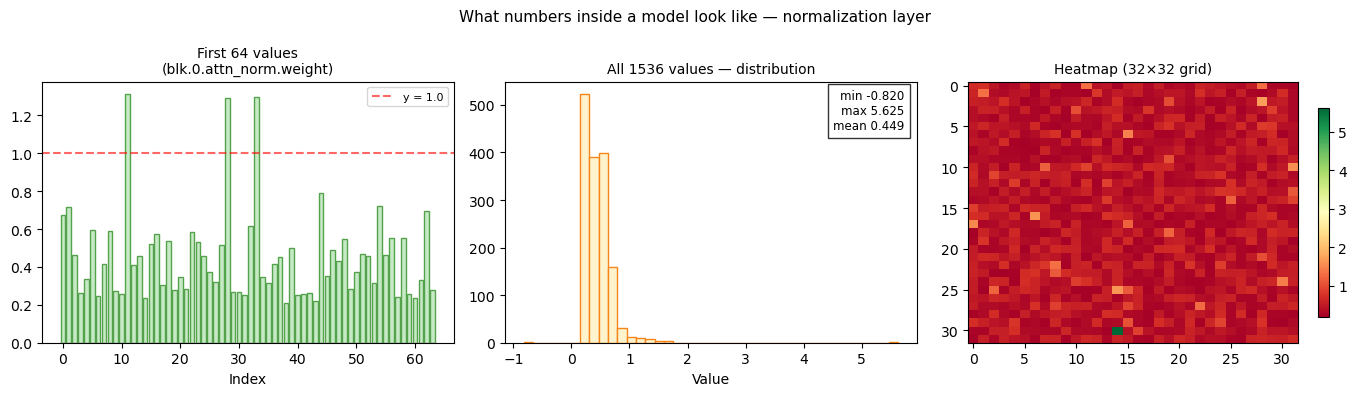

Tensor: blk.0.attn_norm.weight
Mean: 0.449,  Min: -0.820,  Max: 5.625
Values shift during training and vary by model architecture.


In [17]:
# Visualize a normalization tensor (stored as full floats — easy to inspect)
# Most tensors are quantized and can't be read directly — norm weights are an exception
def plot_norm_weights(reader):
    # Find the first normalization tensor in layer 0
    norm = next((t for t in reader.tensors if "norm" in t.name and "blk.0" in t.name), None)
    if norm is None:
        print("No normalization tensor found.")
        return

    # Convert to float32 — norm weights are already full precision, no dequantization needed
    vals = norm.data.astype(np.float32)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    # Left: bar chart of first 64 values
    # — red line at 1.0 shows the typical initialization point for comparison
    ax1.bar(range(64), vals[:64], color="#c6e9c6", edgecolor="#54a24b")
    ax1.axhline(1.0, color="red", ls="--", alpha=0.6, label="y = 1.0")
    ax1.set_title(f"First 64 values\n({norm.name})", fontsize=10)
    ax1.set_xlabel("Index"); ax1.legend(fontsize=8)

    # Middle: histogram of all values — shows the full distribution
    ax2.hist(vals, bins=40, color="#fff3cd", edgecolor="#f58518")
    ax2.set_title(f"All {len(vals)} values — distribution", fontsize=10)
    ax2.set_xlabel("Value")
    stats = f"min {vals.min():.3f}\nmax {vals.max():.3f}\nmean {vals.mean():.3f}"
    ax2.text(0.97, 0.97, stats, transform=ax2.transAxes, va="top", ha="right",
             fontsize=8.5, bbox=dict(facecolor="white", alpha=0.8))

    # Right: same values as a heatmap — color encodes magnitude
    im = ax3.imshow(vals[:32*32].reshape(32, 32), cmap="RdYlGn", aspect="auto")
    ax3.set_title("Heatmap (32×32 grid)", fontsize=10)
    plt.colorbar(im, ax=ax3, shrink=0.8)

    plt.suptitle("What numbers inside a model look like — normalization layer", fontsize=11)
    plt.tight_layout()
    plt.show()

    # Note: values are not necessarily close to 1.0 — this depends on the normalization type.
    # RMSNorm (used by Qwen2) shifts significantly during training.
    print(f"Tensor: {norm.name}")
    print(f"Mean: {vals.mean():.3f},  Min: {vals.min():.3f},  Max: {vals.max():.3f}")
    print("Values shift during training and vary by model architecture.")

plot_norm_weights(reader)

## Section 5. Understanding Embeddings

Each token ID maps to a **dense vector** — a list of 1,536 floating-point 
numbers called an **embedding**.

> **Building on Section 4:** You already saw that `token_embd.weight` has shape  
> `151,936 tokens × 1,536 dimensions`. Now we'll look at what those 1,536 numbers actually mean.

Think of it like a map: every word gets coordinates, and words with similar 
meanings end up living close to each other on the map.

These vectors are not arbitrary. After training, tokens with similar meanings 
end up with similar vectors:
```
"inflation" → [ 0.12, -0.34,  0.78, ...]   # 1,536 floats — one vector per token
"deflation" → [ 0.11, -0.31,  0.75, ...]   # very similar to inflation
"banana"    → [-0.45,  0.22, -0.19, ...]   # completely unrelated
```
Similarity between two vectors is measured with **cosine similarity**.  
Think of it like the angle between two arrows: arrows pointing in nearly 
the same direction score close to 1.0, while arrows pointing in completely 
different directions score close to 0.

### Switching to embedding mode

So far we used the model to **generate text** — predicting the next token.
Now we want to use it differently: to extract **embedding vectors** from words.

Both modes run the same Transformer layers, but they read different outputs:
- **Generation mode** looks at the final logits — scores over the vocabulary 
  to pick the next token
- **Embedding mode** looks at the intermediate vectors — the hidden states 
  that represent meaning

`llama-cpp-python` requires you to choose one mode at load time, and running 
both simultaneously would exhaust memory. So we release the generation model 
first, then reload it in embedding mode.

In [53]:
# Load the model in embedding mode
# — embedding=True returns vector representations instead of generated text
print("⏳ Loading embedding model...")
embed_model = Llama(model_path=MODEL_PATH, embedding=True, n_ctx=128, verbose=False)
print("✅ Ready.")

def get_embedding(text):
    # embed() returns one vector per token — shape (n_tokens, dim)
    # we average across tokens to get a single vector representing the whole text
    arr = np.array(embed_model.embed(text), dtype=np.float32)
    return arr.mean(axis=0) if arr.ndim == 2 else arr

def cosine_sim(v1, v2):
    # cosine similarity = dot product / (magnitude of v1 × magnitude of v2)
    # ranges from 0 (completely unrelated) to 1 (identical direction)
    # we guard against division by zero with the `if d > 0` check
    d = np.linalg.norm(v1) * np.linalg.norm(v2)
    return float(np.dot(v1, v2) / d) if d > 0 else 0.0

⏳ Loading embedding model...


llama_context: n_ctx_per_seq (128) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


✅ Ready.


In [54]:
# Compute embeddings for a set of economics words
# — each word becomes a vector of {dim} floats
econ_words = [
    "inflation", "deflation", "tariff", "trade",
    "GDP", "recession", "growth", "supply",
    "demand", "price", "interest", "bank"
]

# convert each word to a vector and store in a dictionary: {"inflation": array([...]), ...}
embeddings = {w: get_embedding(w) for w in econ_words}

# all vectors have the same dimension — grab any one to check
dim = next(iter(embeddings.values())).shape[0]
print(f"Embeddings ready. Vector dimension: {dim:,}")

Embeddings ready. Vector dimension: 1,536


### Similarity Heatmap

Each cell shows the cosine similarity between two words — how close 
their vectors are in the 1,536-dimensional embedding space.

- **Darker = more similar** meaning
- **Lighter = less related**

The diagonal is always 1.0 — every word is identical to itself.

Look for clusters: do price-related words (`inflation`, `deflation`, `price`) 
group together? Do macro words (`GDP`, `recession`, `growth`) form their own cluster?
This structure was never hand-coded — the model learned it entirely from text.

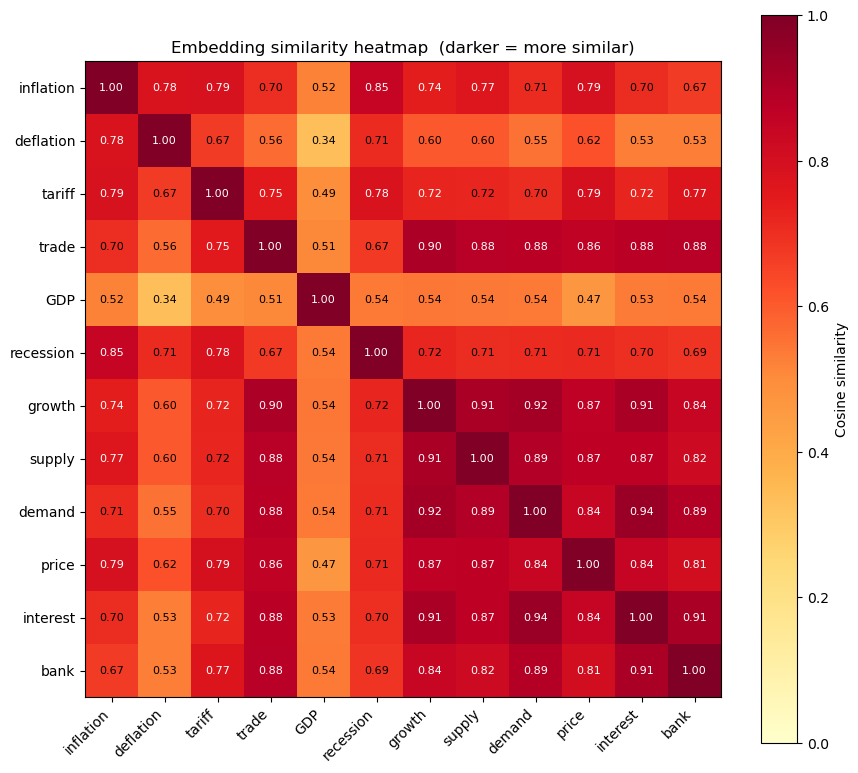

In [55]:
# Cosine similarity heatmap
def plot_similarity_heatmap(words, embeddings):
    n   = len(words)

    # build an n×n matrix — entry [i,j] is the cosine similarity between word i and word j
    # the diagonal is always 1.0 (every word is identical to itself)
    sim = np.array([[cosine_sim(embeddings[w1], embeddings[w2])
                     for w2 in words] for w1 in words])

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(sim, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(words, fontsize=10)
    ax.set_title("Embedding similarity heatmap  (darker = more similar)")

    # annotate each cell with its value
    # use white text on dark cells, black text on light cells — for readability
    for i in range(n):
        for j in range(n):
            val = sim[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if val > 0.72 else "black")

    plt.colorbar(im, ax=ax, label="Cosine similarity")
    plt.tight_layout()
    plt.show()

plot_similarity_heatmap(econ_words, embeddings)

**What to look for:**

- The diagonal is always 1.0 — every word is identical to itself
- `growth`, `supply`, `demand`, `interest`, `bank` form a tight cluster (0.84–0.94) 
  — the model learned these concepts are closely related
- `GDP` scores low with almost everything (0.34–0.54) — it's an acronym, 
  and the model didn't connect it as strongly to other economics words
- `inflation` / `deflation` = 0.78 — similar, but not as close as you might expect

This structure was never hand-coded — it emerged entirely from patterns in text.

### 🎮 Try it yourself!
Type any two words and see how similar their embeddings are.
Try pairs like `supply` / `demand`, or `GDP` / `banana` to see the difference!

In [21]:
# Interactive: compare any two words
w1_box  = widgets.Text(value="inflation",  description="Word 1:", layout=widgets.Layout(width="260px"))
w2_box  = widgets.Text(value="recession",  description="Word 2:", layout=widgets.Layout(width="260px"))
cmp_btn = widgets.Button(description="Compare", button_style="success")
cmp_out = widgets.Output()

def _compare(_):
    cmp_out.clear_output()
    with cmp_out:
        w1, w2 = w1_box.value.strip(), w2_box.value.strip()
        if not w1 or not w2:
            print("Enter two words."); return

        score = cosine_sim(get_embedding(w1), get_embedding(w2))
        pct   = int(score * 100)  # convert to percentage for the progress bar width

        # color and label change based on similarity threshold
        color = "#54a24b" if score > 0.8 else "#f58518" if score > 0.6 else "#e45756"
        label = "Highly similar" if score > 0.8 else "Moderately similar" if score > 0.6 else "Not very related"

        display(HTML(f"""
        <div style="font-family:sans-serif; padding:16px; background:#fafbfc;
                    border:1px solid #d0d7de; border-radius:12px;">
          <b style="font-size:15px;">"{w1}" vs "{w2}"</b><br><br>
          <div style="background:#e5e7eb; border-radius:8px; height:26px; width:100%;">
            <div style="background:{color}; width:{pct}%; height:26px; border-radius:8px;
                        display:flex; align-items:center; padding-left:10px;
                        color:white; font-weight:bold;">{score:.3f}</div>
          </div>
          <div style="margin-top:8px; color:{color}; font-weight:bold;">{label}</div>
          <div style="margin-top:6px; font-size:12px; color:#666;">
            Cosine similarity = {score:.4f} &nbsp;|&nbsp; range 0 (unrelated) → 1 (identical direction)
          </div>
        </div>
        """))

cmp_btn.on_click(_compare)
display(widgets.VBox([widgets.HBox([w1_box, w2_box]), cmp_btn, cmp_out]))
_compare(None)  # run once automatically with the default values

## Section 6. Semantic Geometry

Embedding vectors do not just measure similarity — they encode **geometric 
relationships** between concepts.

Each word lives in a space with 1,536 dimensions — impossible to visualize directly.
**PCA (Principal Component Analysis)** solves this by finding the two directions 
in that space that capture the most variation, then projecting everything onto them.
Think of it like casting a shadow: the shadow isn't the object, but it preserves 
the overall shape.

Some information is lost in this compression — two words that look close in 2D 
might actually be further apart in the full 1,536-dimensional space. But the 
broad structure stays visible: clusters that appear together are genuinely related.

This is not hand-coded — the model learned these relationships entirely from 
patterns in text.

### Words on a Map

Each dot is a word, projected from 1,536 dimensions down to 2.
Same-color dots belong to the same hand-labeled group:

- 🔴 **Price** — inflation, deflation, price
- 🔵 **Trade** — tariff, trade, supply, demand  
- 🟢 **Macro** — GDP, recession, growth, interest, bank

Do the colors cluster together, or are they scattered randomly?
If the model learned meaningful structure, same-color words should end up close to each other —
even though we never told it about these groups.

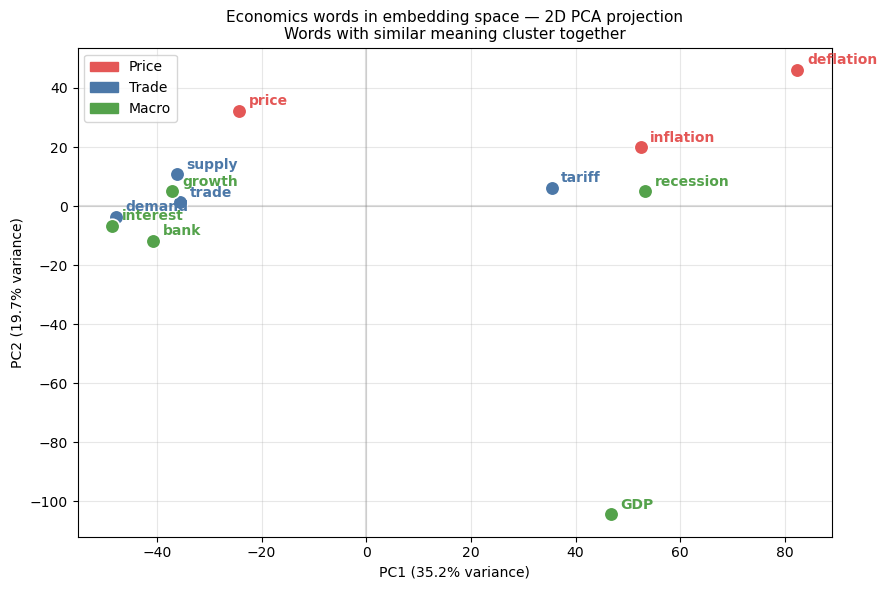

In [56]:
# 2D PCA projection with group coloring
def plot_embedding_space(words, embeddings):

    # hand-labeled groups — the model doesn't know about these categories
    # we use them only for coloring the plot
    groups   = {
        "Price":   ["inflation", "deflation", "price"],
        "Trade":   ["tariff", "trade", "supply", "demand"],
        "Macro":   ["GDP", "recession", "growth", "interest", "bank"],
    }
    g_colors = {"Price": "#e45756", "Trade": "#4c78a8", "Macro": "#54a24b"}

    # build a reverse lookup: word → group name
    word_to_group = {w: g for g, ws in groups.items() for w in ws}

    # stack all vectors into a matrix, then fit PCA
    # PCA finds the 2 directions that capture the most variance in the data
    vectors = np.array([embeddings[w] for w in words])
    pca     = PCA(n_components=2)
    coords  = pca.fit_transform(vectors)  # shape: (n_words, 2)

    fig, ax = plt.subplots(figsize=(9, 6))
    for i, word in enumerate(words):
        col = g_colors[word_to_group[word]]
        ax.scatter(coords[i, 0], coords[i, 1], color=col, s=110,
                   edgecolors="white", linewidths=1.2, zorder=3)
        ax.annotate(word, (coords[i, 0], coords[i, 1]),
                    xytext=(7, 4), textcoords="offset points",
                    fontsize=10, fontweight="bold", color=col)

    legend = [mpatches.Patch(color=c, label=g) for g, c in g_colors.items()]
    ax.legend(handles=legend, fontsize=10)
    ax.set_title("Economics words in embedding space — 2D PCA projection\n"
                 "Words with similar meaning cluster together", fontsize=11)

    # axis labels show how much variance each principal component captures
    # PC1 + PC2 together tell you how much of the original structure is preserved
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", alpha=0.25)
    ax.axvline(0, color="gray", alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_embedding_space(econ_words, embeddings)

**What this map tells us:**

- `supply`, `demand`, `trade`, `growth`, `interest`, `bank` cluster tightly on the left — 
  the model treats these as closely related regardless of our hand-labeled groups
- `GDP` sits far from everyone — acronyms are often weakly connected to related concepts
- `tariff` is isolated from its Trade group — it has a more specific, policy-related meaning
- The colors don't form perfect clusters — and that's the point. 
  The model learned its own structure from text, not from our categories.

PC1 + PC2 capture only 55% of the variance — the remaining 45% is invisible in this 2D view,
so some distances here are misleading.

<div style="font-family:sans-serif; padding:24px; background:#fafbfc;
            border:1px solid #d0d7de; border-radius:12px;">
  <h2 style="margin-top:0;">🎯 Final Takeaways</h2>
  <ul style="line-height:2;">
    <li><b>Text becomes token IDs.</b> The model never reads raw letters — only integers from a fixed vocabulary.</li>
    <li><b>Generation happens one token at a time.</b> Each step runs the full pipeline and picks one integer.</li>
    <li><b>GGUF stores both metadata and tensors.</b> Everything needed to run a model lives in one file — metadata first, so you can inspect architecture without loading weights.</li>
    <li><b>Most parameters live in feed-forward layers, not attention.</b> Attention decides where to look; FFN is where knowledge is stored.</li>
    <li><b>Embeddings map words into a geometric space.</b> Similar words end up with similar vectors — and the structure clusters by meaning.</li>
    <li><b>This structure emerged from training</b> — not from hand-coding.</li>
  </ul>
</div>

---

### Further Reading
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — visual walkthrough of attention
- [Tokenizer visualizer](https://tiktokenizer.vercel.app/) — explore tokenization interactively
- [GGUF specification](https://github.com/ggerganov/ggml/blob/master/docs/gguf.md) — full binary format documentation
- [The Illustrated Word2Vec](https://jalammar.github.io/illustrated-word2vec/) — deeper dive into embedding spaces
- [llama-cpp-python docs](https://llama-cpp-python.readthedocs.io/)

### Cleanup

Release all models and file handles from memory.
Run this cell when you are done with the notebook.

In [23]:
# Clean up — free memory after the notebook is done
del embed_model
del reader
import gc; gc.collect()
print("Notebook complete. ✅")

Notebook complete. ✅
